# 05 Detección de Zonas de Riesgo - DBSCAN
**Curso:** Agentes Inteligentes | **Grupo 5**

### Estructura del notebook

| Sección | Descripción | Input |
|---|---|---|
| 1. Carga y verificación | Dataset completo sin SMOTE | `siniestros_modelado.csv` |
| 2. Extracción de coordenadas | Latitud y longitud originales | `df` |
| 3. Normalización | Copia para DBSCAN - coordenadas originales intactas | `coords_norm` |
| 4. Selección de parámetros | K-distance plot para `eps` óptimo | `coords_norm` |
| 5. DBSCAN | Clustering espacial | `coords_norm` |
| 6. Análisis de clusters | Severidad por cluster, ruido | `df` + labels |
| 7. Visualización geográfica | Mapa sobre coordenadas reales | `df` |
| 8. Interpretación | Hallazgos conectados a pregunta de investigación | - |
| 9. Exportación | Dataset con cluster asignado | `siniestros_clusters.csv` |

> **Fuente metodológica:** Kamh et al. - clustering espacial de hotspots viales.
> Ester et al. (1996) - selección de parámetros DBSCAN via k-distance plot.
> Han et al. (2012) - normalización obligatoria previa a algoritmos de distancia.


In [26]:
import sys
print(sys.executable)

/home/node-vault07/projects/siniestros-fatales-peru-ml/.venv/bin/python


## 0. Imports y configuración

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

DIR_PROCESADA = BASE_DIR / 'data' / 'procesada'
DIR_FIGURAS   = BASE_DIR / 'outputs' / 'figures'
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)


## 1. Carga y verificación

Se carga `siniestros_modelado.csv` - el dataset completo sin SMOTE exportado
por el Notebook 03. Este archivo contiene las features encodeadas y la variable
objetivo, pero las coordenadas deben verificarse como numéricas reales antes
de cualquier operación espacial.


In [28]:
df = pd.read_csv(DIR_PROCESADA / 'siniestros_modelado.csv', encoding='utf-8')

print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Nulos: {df.isnull().sum().sum()}')

# Detectar columnas dinámicamente
col_lat    = next((c for c in df.columns if 'LATITUD'   in c.upper()), None)
col_lon    = next((c for c in df.columns if 'LONGITUD'  in c.upper()), None)
col_target = next((c for c in df.columns if c == 'CATEGORIA_SEVERIDAD'), None)

print(f'\nColumna latitud detectada:  {col_lat}')
print(f'Columna longitud detectada: {col_lon}')
print(f'Variable objetivo detectada: {col_target}')

# Assert: coordenadas deben ser numéricas reales
# El notebook 03 las pudo encodear si pandas las interpretó como object
assert col_lat and col_lon, 'No se encontraron columnas de coordenadas.'
assert pd.api.types.is_numeric_dtype(df[col_lat]), f'{col_lat} no es numérica - verificar encoding en N03.'
assert pd.api.types.is_numeric_dtype(df[col_lon]), f'{col_lon} no es numérica - verificar encoding en N03.'
assert col_target, 'No se encontró CATEGORIA_SEVERIDAD.'

# Verificar rango geográfico coherente con territorio peruano
lat_min, lat_max = df[col_lat].min(), df[col_lat].max()
lon_min, lon_max = df[col_lon].min(), df[col_lon].max()
print(f'\nRango latitud:  [{lat_min:.4f}, {lat_max:.4f}] (Perú esperado: -18.5 a 0.0)')
print(f'Rango longitud: [{lon_min:.4f}, {lon_max:.4f}] (Perú esperado: -81.5 a -68.5)')

assert -19 < lat_min and lat_max < 0,   '[WARNING] Latitud fuera del rango peruano - revisar encoding.'
assert -82 < lon_min and lon_max < -68, '[WARNING] Longitud fuera del rango peruano - revisar encoding.'

print('\n[SUCCESS] Coordenadas verificadas como numéricas y dentro del territorio peruano.')
print(f'\nDistribución de {col_target}:')
print(df[col_target].value_counts())


Dimensiones: 9,106 filas × 80 columnas
Nulos: 0

Columna latitud detectada:  COORDENADAS LATITUD
Columna longitud detectada: COORDENADAS  LONGITUD
Variable objetivo detectada: CATEGORIA_SEVERIDAD

Rango latitud:  [-18.3054, -3.4829] (Perú esperado: -18.5 a 0.0)
Rango longitud: [-81.2889, -68.9531] (Perú esperado: -81.5 a -68.5)

[SUCCESS] Coordenadas verificadas como numéricas y dentro del territorio peruano.

Distribución de CATEGORIA_SEVERIDAD:
CATEGORIA_SEVERIDAD
LEVE                7652
GRAVE_MORTALIDAD     929
GRAVE_LESIONADOS     525
Name: count, dtype: int64


## 2. Extracción de coordenadas originales

Se extraen las coordenadas en un objeto separado para preservarlas intactas.
El objeto `coords_orig` se usará para las visualizaciones geográficas.
El objeto `coords_norm` se usará exclusivamente para DBSCAN.

In [29]:
# Eliminar filas con coordenadas nulas si las hubiera
n_antes = len(df)
df = df.dropna(subset=[col_lat, col_lon]).reset_index(drop=True)
n_eliminadas = n_antes - len(df)
if n_eliminadas > 0:
    print(f'[WARNING] {n_eliminadas} filas eliminadas por coordenadas nulas.')
else:
    print('[SUCCESS] Sin filas eliminadas - todas las coordenadas son válidas.')

# Coordenadas originales - para mapas
coords_orig = df[[col_lat, col_lon]].values

print(f'\nRegistros disponibles para clustering: {len(coords_orig):,}')
print(f'Shape coords_orig: {coords_orig.shape}')


[SUCCESS] Sin filas eliminadas - todas las coordenadas son válidas.

Registros disponibles para clustering: 9,106
Shape coords_orig: (9106, 2)


## 3. Normalización

DBSCAN usa distancia euclidiana. En el territorio peruano, un grado de latitud
equivale a ~111 km, pero un grado de longitud equivale a ~85 km en el ecuador
y menos hacia el sur. Sin normalización, DBSCAN trataría ambas dimensiones como
equivalentes, distorsionando los clusters (Han et al., 2012).

Se normaliza con `StandardScaler` sobre una **copia** de las coordenadas.
Las coordenadas originales (`coords_orig`) permanecen intactas para los mapas.


In [30]:
scaler = StandardScaler()
coords_norm = scaler.fit_transform(coords_orig)

print('Normalización aplicada con StandardScaler.')
print(f'Media latitud normalizada:   {coords_norm[:,0].mean():.4f} (debe ser ~0)')
print(f'Std latitud normalizada:     {coords_norm[:,0].std():.4f} (debe ser ~1)')
print(f'Media longitud normalizada:  {coords_norm[:,1].mean():.4f} (debe ser ~0)')
print(f'Std longitud normalizada:    {coords_norm[:,1].std():.4f} (debe ser ~1)')


Normalización aplicada con StandardScaler.
Media latitud normalizada:   0.0000 (debe ser ~0)
Std latitud normalizada:     1.0000 (debe ser ~1)
Media longitud normalizada:  0.0000 (debe ser ~0)
Std longitud normalizada:    1.0000 (debe ser ~1)


## 4. Selección de parámetros - K-distance plot

DBSCAN requiere dos parámetros: `eps` (radio de vecindad) y `min_samples`
(mínimo de puntos para formar un cluster). Hardcodearlos sin análisis previo
produce resultados arbitrarios.

**Método:** k-distance plot (Ester et al., 1996). Se calcula la distancia
al k-ésimo vecino más cercano para cada punto, se ordenan de mayor a menor
y se busca el "codo" - el punto donde la curva cambia de pendiente bruscamente.
Ese valor es el `eps` óptimo. `k = min_samples - 1`.

Se evalúan dos valores de `min_samples` para comparar granularidad.


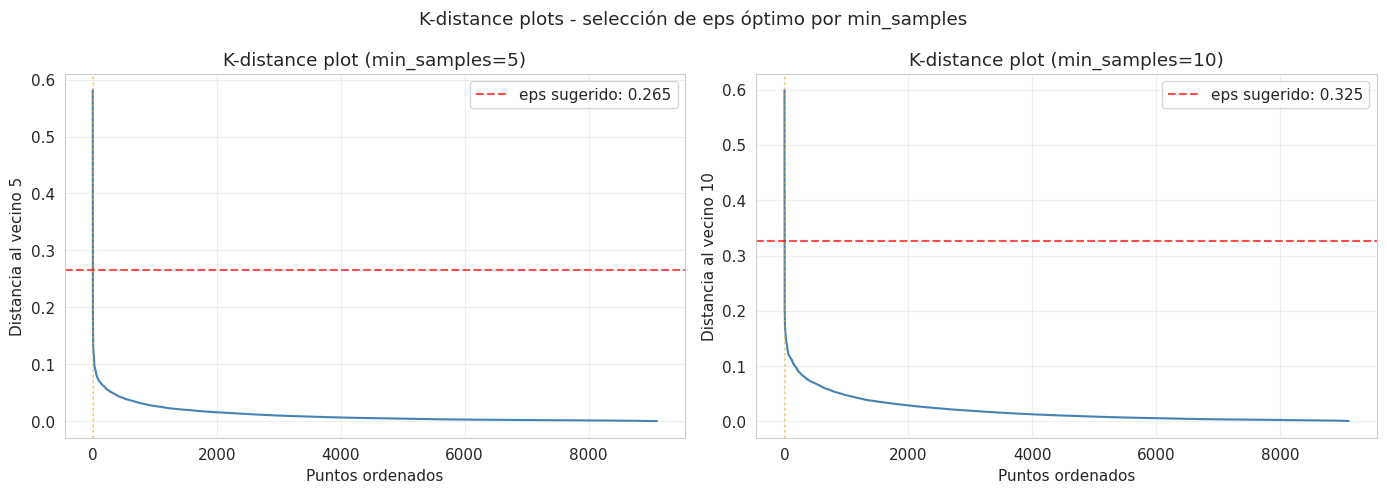


Eps recomendados por min_samples:
  min_samples=5: eps=0.2652
  min_samples=10: eps=0.3254

Nota: el codo detectado automáticamente es una guía.
Ajustar manualmente si el plot muestra un codo más claro en otro punto.


In [31]:
# Evaluar dos valores de min_samples
MIN_SAMPLES_CANDIDATOS = [5, 10]
fig, axes = plt.subplots(1, len(MIN_SAMPLES_CANDIDATOS), figsize=(14, 5))

eps_recomendados = {}

for ax, ms in zip(axes, MIN_SAMPLES_CANDIDATOS):
    nbrs = NearestNeighbors(n_neighbors=ms).fit(coords_norm)
    distancias, _ = nbrs.kneighbors(coords_norm)
    dist_k = np.sort(distancias[:, ms-1])[::-1]

    ax.plot(dist_k, linewidth=1.5, color='steelblue')
    ax.set_title(f'K-distance plot (min_samples={ms})')
    ax.set_xlabel('Puntos ordenados')
    ax.set_ylabel(f'Distancia al vecino {ms}')
    ax.grid(True, alpha=0.3)

    # Detectar codo automáticamente por máxima curvatura
    diffs = np.diff(dist_k)
    codo_idx = np.argmax(np.abs(np.diff(diffs))) + 1
    eps_codo = dist_k[codo_idx]
    eps_recomendados[ms] = eps_codo
    ax.axhline(eps_codo, color='red', linestyle='--', alpha=0.7,
               label=f'eps sugerido: {eps_codo:.3f}')
    ax.axvline(codo_idx, color='orange', linestyle=':', alpha=0.5)
    ax.legend()

plt.suptitle('K-distance plots - selección de eps óptimo por min_samples')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'kdistance_dbscan.png', dpi=150)
plt.show()

print('\nEps recomendados por min_samples:')
for ms, eps in eps_recomendados.items():
    print(f'  min_samples={ms}: eps={eps:.4f}')
print('\nNota: el codo detectado automáticamente es una guía.')
print('Ajustar manualmente si el plot muestra un codo más claro en otro punto.')


In [32]:
for eps_test in [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15]:
    db_test = DBSCAN(eps=eps_test, min_samples=5, n_jobs=-1).fit(coords_norm)
    labels_test = db_test.labels_
    n_cl = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_ruido = (labels_test == -1).sum()
    cluster_mayor = max([(labels_test == c).sum() for c in set(labels_test) if c != -1], default=0)
    print(f'eps={eps_test:.3f} | clusters={n_cl:3d} | ruido={n_ruido:5,} ({n_ruido/len(labels_test)*100:4.1f}%) | cluster mayor={cluster_mayor:5,} ({cluster_mayor/len(labels_test)*100:4.1f}%)')

eps=0.010 | clusters=222 | ruido=2,451 (26.9%) | cluster mayor=1,743 (19.1%)
eps=0.020 | clusters=164 | ruido=1,067 (11.7%) | cluster mayor=1,987 (21.8%)
eps=0.030 | clusters= 96 | ruido=  592 ( 6.5%) | cluster mayor=2,018 (22.2%)
eps=0.050 | clusters= 51 | ruido=  156 ( 1.7%) | cluster mayor=3,063 (33.6%)
eps=0.080 | clusters= 10 | ruido=   28 ( 0.3%) | cluster mayor=8,503 (93.4%)
eps=0.100 | clusters=  5 | ruido=    9 ( 0.1%) | cluster mayor=8,938 (98.2%)
eps=0.150 | clusters=  3 | ruido=    3 ( 0.0%) | cluster mayor=8,996 (98.8%)


In [33]:
# Selección final de parámetros
# Modificar estos valores si el k-distance plot sugiere un codo distinto
MIN_SAMPLES = 5
EPS = 0.05  # elegido tras barrido manual: eps=0.265 (automático) colapsaba
            # todo en 1 cluster (98.8%); 0.05 es el último punto antes del
            # "chaining" (cluster mayor pasa de 33.6% a 93.4% entre 0.05 y 0.08)

print(f'Parámetros seleccionados:')
print(f'  eps         = {EPS:.4f}')
print(f'  min_samples = {MIN_SAMPLES}')


Parámetros seleccionados:
  eps         = 0.0500
  min_samples = 5


## 5. Aplicación de DBSCAN

DBSCAN clasifica cada punto como:
- **Core point**: tiene al menos `min_samples` vecinos dentro de `eps`
- **Border point**: está dentro del `eps` de un core point pero no es core
- **Ruido** (label = -1): no pertenece a ningún cluster

Los puntos de ruido no se ignoran - se reportan y analizan porque pueden
representar siniestros aislados en zonas remotas (Ester et al., 1996).


In [34]:
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
labels = db.fit_predict(coords_norm)

# Asignar labels al dataframe original
df['CLUSTER'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido    = (labels == -1).sum()

print(f'Clusters encontrados: {n_clusters}')
print(f'Puntos de ruido:      {n_ruido:,} ({n_ruido/len(labels)*100:.1f}%)')
print(f'Puntos en clusters:   {(labels != -1).sum():,} ({(labels != -1).sum()/len(labels)*100:.1f}%)')
print(f'\nTamaño de clusters:')
for cl in sorted(set(labels)):
    n = (labels == cl).sum()
    nombre = 'RUIDO' if cl == -1 else f'Cluster {cl}'
    print(f'  {nombre}: {n:,} puntos')


Clusters encontrados: 51
Puntos de ruido:      156 (1.7%)
Puntos en clusters:   8,950 (98.3%)

Tamaño de clusters:
  RUIDO: 156 puntos
  Cluster 0: 2,037 puntos
  Cluster 1: 1,877 puntos
  Cluster 2: 251 puntos
  Cluster 3: 425 puntos
  Cluster 4: 3,063 puntos
  Cluster 5: 63 puntos
  Cluster 6: 11 puntos
  Cluster 7: 346 puntos
  Cluster 8: 86 puntos
  Cluster 9: 14 puntos
  Cluster 10: 13 puntos
  Cluster 11: 14 puntos
  Cluster 12: 8 puntos
  Cluster 13: 130 puntos
  Cluster 14: 11 puntos
  Cluster 15: 108 puntos
  Cluster 16: 5 puntos
  Cluster 17: 6 puntos
  Cluster 18: 40 puntos
  Cluster 19: 8 puntos
  Cluster 20: 114 puntos
  Cluster 21: 38 puntos
  Cluster 22: 15 puntos
  Cluster 23: 65 puntos
  Cluster 24: 12 puntos
  Cluster 25: 6 puntos
  Cluster 26: 7 puntos
  Cluster 27: 6 puntos
  Cluster 28: 7 puntos
  Cluster 29: 10 puntos
  Cluster 30: 6 puntos
  Cluster 31: 9 puntos
  Cluster 32: 6 puntos
  Cluster 33: 14 puntos
  Cluster 34: 9 puntos
  Cluster 35: 11 puntos
  Cluste

## 6. Análisis de severidad por cluster

Se analiza la distribución de `CATEGORIA_SEVERIDAD` dentro de cada cluster
para identificar cuáles concentran mayor proporción de siniestros graves.


In [35]:
# Distribución de severidad por cluster
resumen_clusters = df.groupby('CLUSTER')[col_target].value_counts(normalize=True).unstack(fill_value=0)
resumen_clusters['TOTAL'] = df.groupby('CLUSTER').size()
resumen_clusters = resumen_clusters.sort_values('TOTAL', ascending=False)

print('=== Proporción de severidad por cluster ===')
print(resumen_clusters.round(3).to_string())

# Identificar clusters con alta proporción de casos graves
col_grave = 'GRAVE_MORTALIDAD' if 'GRAVE_MORTALIDAD' in resumen_clusters.columns else None
if col_grave:
    umbral = resumen_clusters[col_grave].mean() * 1.5
    clusters_criticos = resumen_clusters[resumen_clusters[col_grave] > umbral].index.tolist()
    clusters_criticos = [c for c in clusters_criticos if c != -1]
    print(f'\nClusters con proporción de GRAVE_MORTALIDAD > {umbral:.2f} (1.5x la media):')
    print(f'  {clusters_criticos}')


=== Proporción de severidad por cluster ===
CATEGORIA_SEVERIDAD  GRAVE_LESIONADOS  GRAVE_MORTALIDAD   LEVE  TOTAL
CLUSTER                                                              
 4                              0.067             0.124  0.808   3063
 0                              0.030             0.043  0.927   2037
 1                              0.066             0.121  0.814   1877
 3                              0.045             0.078  0.878    425
 7                              0.084             0.092  0.824    346
 2                              0.036             0.044  0.920    251
-1                              0.109             0.276  0.615    156
 13                             0.069             0.031  0.900    130
 20                             0.070             0.140  0.789    114
 15                             0.037             0.083  0.880    108
 8                              0.128             0.116  0.756     86
 23                             0.015         

In [36]:
# Composición departamental por cluster
# DEPARTAMENTO en siniestros_modelado.csv fue frequency-encoded (numérico).
# Se recupera el nombre original desde siniestros_limpio.csv por posición de fila,
# válido porque ambos archivos conservan las 9,106 filas en el mismo orden.
df_dep = pd.read_csv(DIR_PROCESADA / 'siniestros_limpio.csv',
                     encoding='utf-8',
                     usecols=['DEPARTAMENTO'])

assert len(df_dep) == len(df), \
    f'Desajuste de filas: limpio={len(df_dep)}, modelado={len(df)}'

df['DEPARTAMENTO_ORIG'] = df_dep['DEPARTAMENTO'].values

# Solo clusters con masa suficiente para que los porcentajes sean representativos
MIN_CLUSTER = 50
baseline_gm = (df[col_target] == 'GRAVE_MORTALIDAD').mean()
clusters_grandes = resumen_clusters[
    (resumen_clusters.index != -1) & (resumen_clusters['TOTAL'] >= MIN_CLUSTER)
].index.tolist()

print('=== Composición departamental por cluster (top 3 departamentos) ===\n')
for cl_id in sorted(clusters_grandes,
                    key=lambda x: resumen_clusters.loc[x, 'TOTAL'],
                    reverse=True):
    total  = int(resumen_clusters.loc[cl_id, 'TOTAL'])
    pct_gm = resumen_clusters.loc[cl_id, col_grave] if col_grave else 0
    top_dep = (df[df['CLUSTER'] == cl_id]['DEPARTAMENTO_ORIG']
               .value_counts()
               .head(3))
    flag = ' ← HOTSPOT' if pct_gm > baseline_gm else ''
    print(f'Cluster {cl_id:3d} | n={total:5,} | GRAVE_MORTALIDAD={pct_gm:.1%}{flag}')
    for dep, cnt in top_dep.items():
        print(f'      {dep}: {cnt:,} ({cnt/total*100:.0f}%)')
    print()

df.drop(columns=['DEPARTAMENTO_ORIG'], inplace=True)

=== Composición departamental por cluster (top 3 departamentos) ===

Cluster   4 | n=3,063 | GRAVE_MORTALIDAD=12.4% ← HOTSPOT
      CUSCO: 792 (26%)
      PUNO: 697 (23%)
      AREQUIPA: 621 (20%)

Cluster   0 | n=2,037 | GRAVE_MORTALIDAD=4.3%
      LIMA: 1,892 (93%)
      CALLAO: 140 (7%)
      ANCASH: 4 (0%)

Cluster   1 | n=1,877 | GRAVE_MORTALIDAD=12.1% ← HOTSPOT
      LA LIBERTAD: 832 (44%)
      CAJAMARCA: 543 (29%)
      LAMBAYEQUE: 317 (17%)

Cluster   3 | n=  425 | GRAVE_MORTALIDAD=7.8%
      PIURA: 425 (100%)

Cluster   7 | n=  346 | GRAVE_MORTALIDAD=9.2%
      ICA: 346 (100%)

Cluster   2 | n=  251 | GRAVE_MORTALIDAD=4.4%
      SAN MARTIN: 251 (100%)

Cluster  13 | n=  130 | GRAVE_MORTALIDAD=3.1%
      TUMBES: 123 (95%)
      PIURA: 7 (5%)

Cluster  20 | n=  114 | GRAVE_MORTALIDAD=14.0% ← HOTSPOT
      ANCASH: 113 (99%)
      ICA: 1 (1%)

Cluster  15 | n=  108 | GRAVE_MORTALIDAD=8.3%
      TACNA: 108 (100%)

Cluster   8 | n=   86 | GRAVE_MORTALIDAD=11.6% ← HOTSPOT
      ICA:

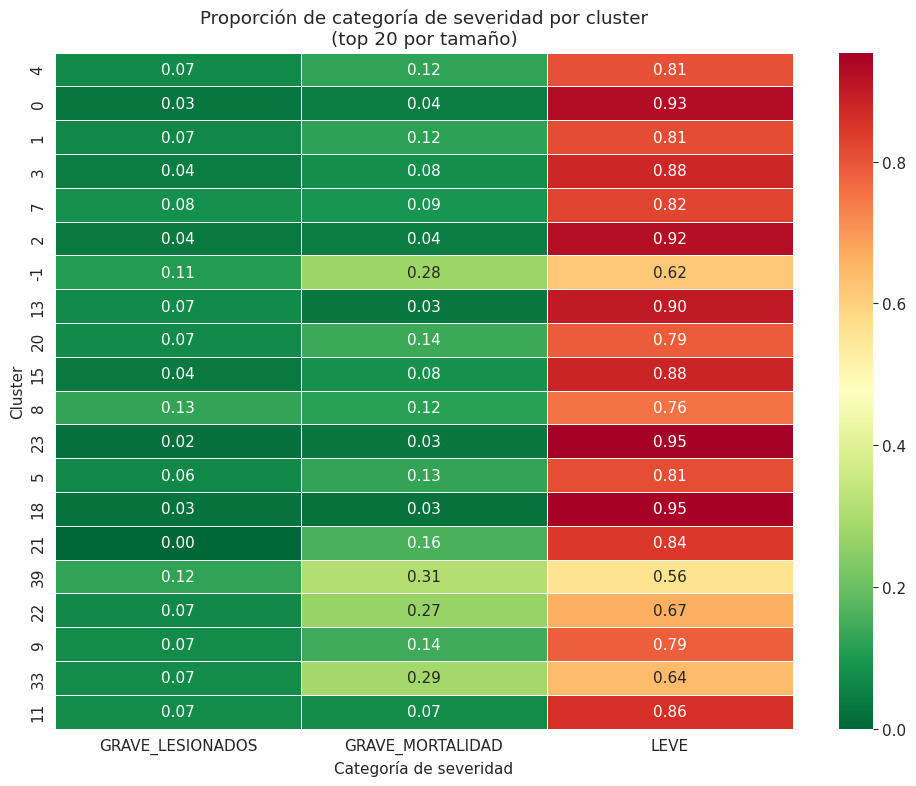

In [37]:
# Heatmap de severidad por cluster (top 20 clusters más grandes)
top_clusters = resumen_clusters.head(20).drop(columns=['TOTAL'], errors='ignore')

if not top_clusters.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(top_clusters) * 0.4)))
    sns.heatmap(top_clusters, annot=True, fmt='.2f', cmap='RdYlGn_r',
                ax=ax, linewidths=0.5)
    ax.set_title('Proporción de categoría de severidad por cluster\n(top 20 por tamaño)')
    ax.set_xlabel('Categoría de severidad')
    ax.set_ylabel('Cluster')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'severidad_por_cluster.png', dpi=150)
    plt.show()


## 7. Visualización geográfica

Los mapas usan las **coordenadas originales** - no las normalizadas.
Se generan dos visualizaciones: clusters detectados y severidad por punto.


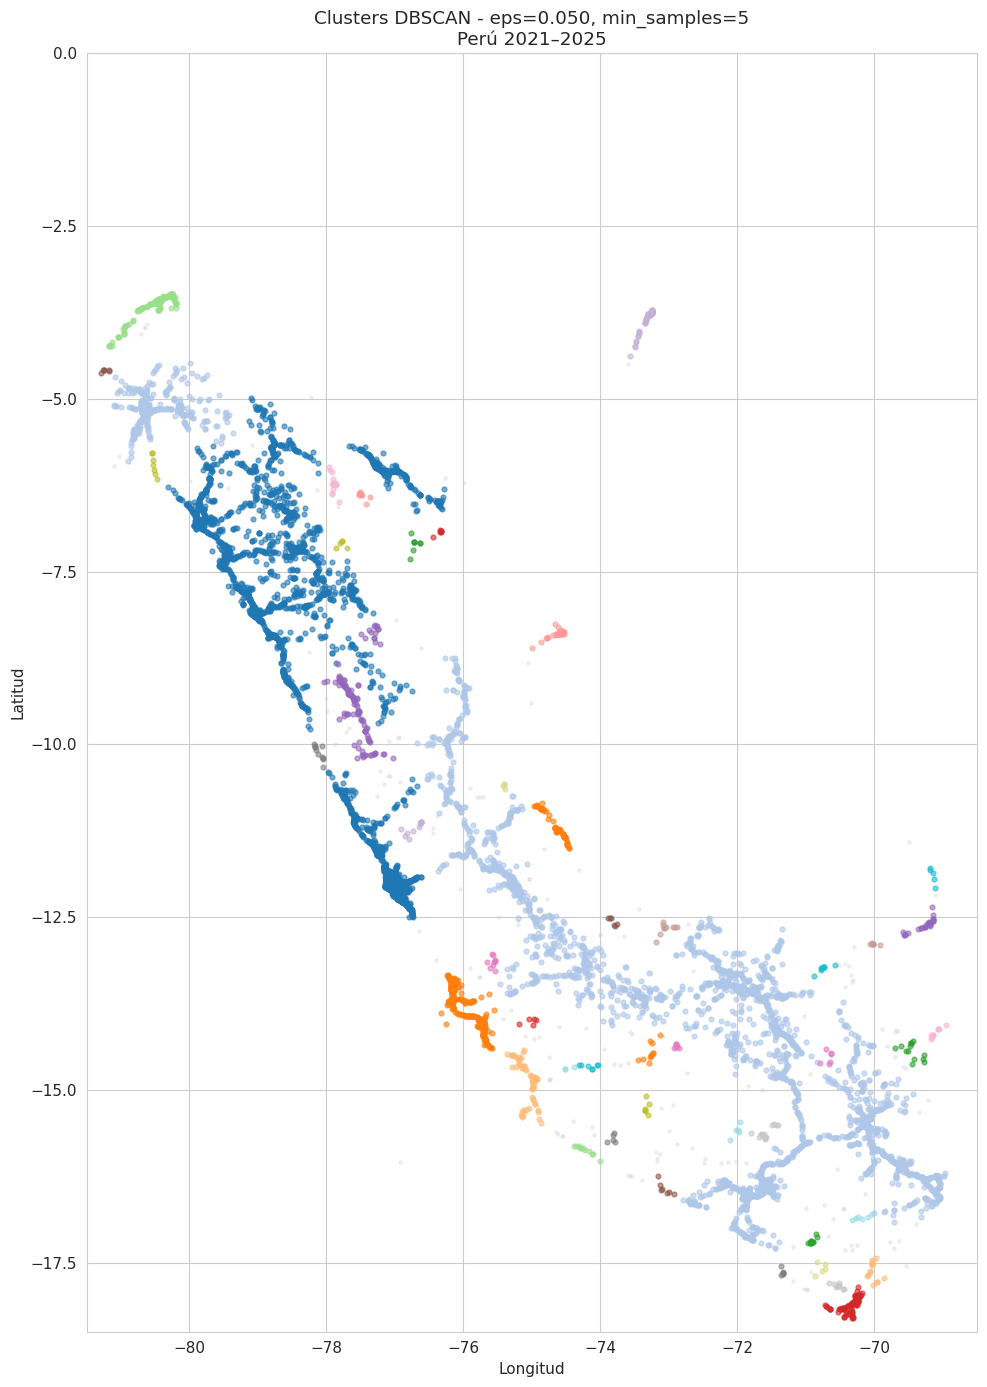

In [38]:
# Mapa 1: clusters detectados
fig, ax = plt.subplots(figsize=(10, 14))

# Ruido en gris
ruido = df[df['CLUSTER'] == -1]
ax.scatter(ruido[col_lon], ruido[col_lat],
           c='lightgray', s=5, alpha=0.3, label=f'Ruido (n={len(ruido):,})')

# Clusters con colores distintos
clusters_unicos = sorted([c for c in df['CLUSTER'].unique() if c != -1])
cmap = plt.colormaps['tab20'].resampled(max(len(clusters_unicos), 1))

for i, cl in enumerate(clusters_unicos):
    subset = df[df['CLUSTER'] == cl]
    ax.scatter(subset[col_lon], subset[col_lat],
               c=[cmap(i)], s=12, alpha=0.6,
               label=f'Cluster {cl} (n={len(subset):,})')

ax.set_xlim(-81.5, -68.5)
ax.set_ylim(-18.5, -0.0)
ax.set_title(f'Clusters DBSCAN - eps={EPS:.3f}, min_samples={MIN_SAMPLES}\nPerú 2021–2025')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
if len(clusters_unicos) <= 15:
    ax.legend(loc='lower right', fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'mapa_clusters_dbscan.png', dpi=150)
plt.show()

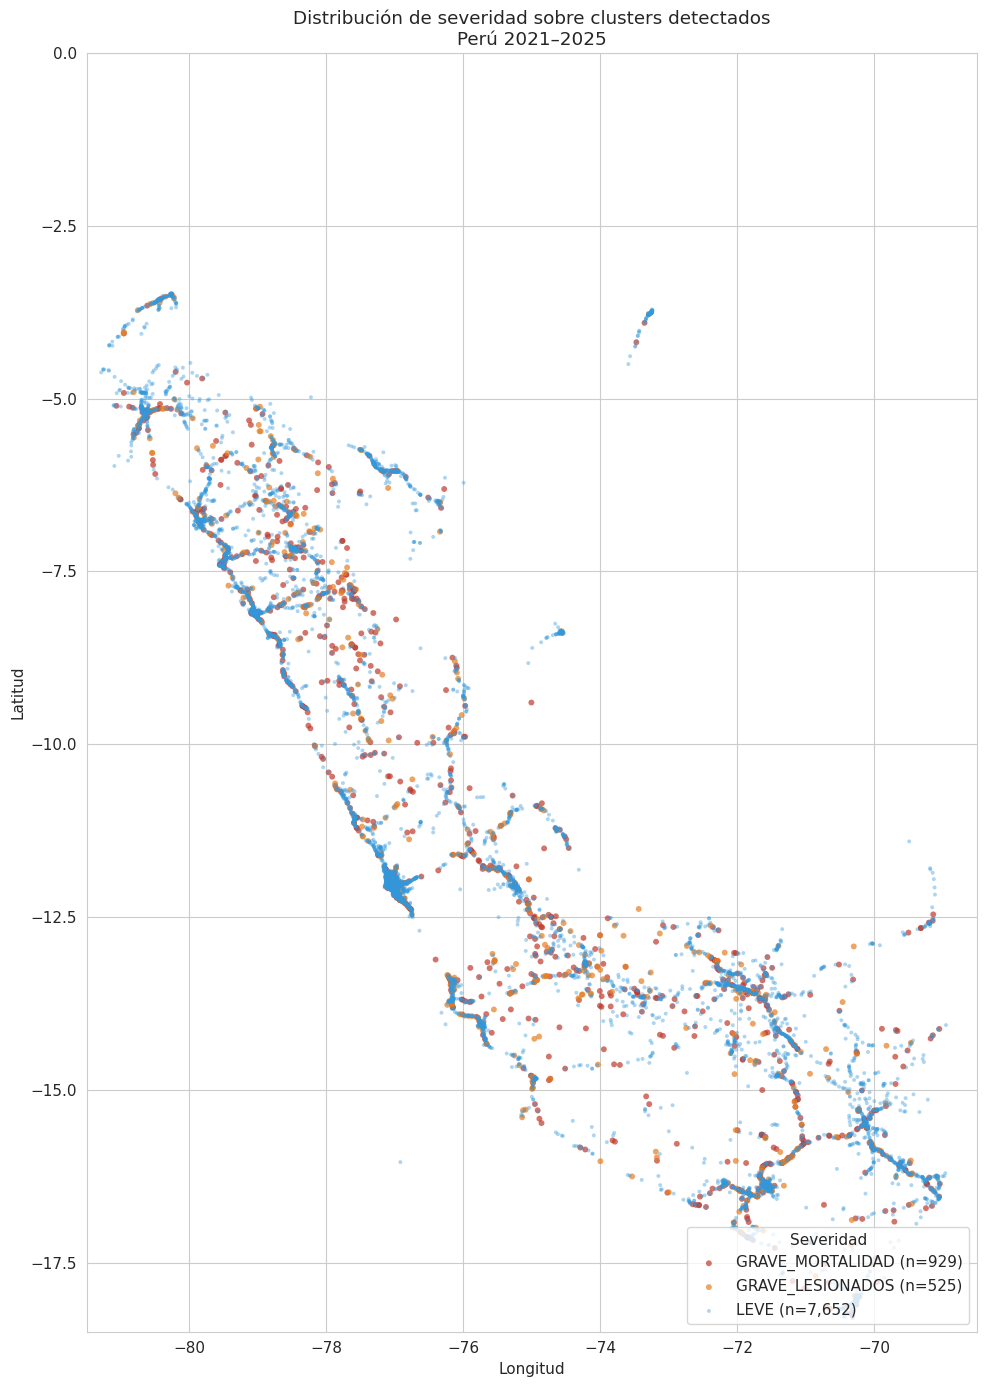

In [39]:
# Mapa 2: severidad sobre clusters
colores_sev = {
    'LEVE'             : '#3498db',
    'GRAVE_LESIONADOS' : '#e67e22',
    'GRAVE_MORTALIDAD' : '#c0392b'
}
orden_plot = ['GRAVE_MORTALIDAD', 'GRAVE_LESIONADOS', 'LEVE']

fig, ax = plt.subplots(figsize=(10, 14))

for categoria in orden_plot:
    if categoria not in df[col_target].values:
        continue
    subset = df[df[col_target] == categoria]
    ax.scatter(subset[col_lon], subset[col_lat],
               c=colores_sev.get(categoria, 'gray'),
               label=f'{categoria} (n={len(subset):,})',
               alpha=0.4 if categoria == 'LEVE' else 0.7,
               s=8 if categoria == 'LEVE' else 18,
               edgecolors='none')

ax.set_xlim(-81.5, -68.5)
ax.set_ylim(-18.5, -0.0)
ax.set_title('Distribución de severidad sobre clusters detectados\nPerú 2021–2025')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(title='Severidad', loc='lower right')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'mapa_severidad_clusters.png', dpi=150)
plt.show()


## 8. Interpretación de resultados


In [40]:
# Resumen cuantitativo para la interpretación
print('=== Resumen para interpretación ===')
print(f'Total clusters:        {n_clusters}')
print(f'Total puntos en ruido: {n_ruido:,} ({n_ruido/len(df)*100:.1f}%)')

if col_grave:
    baseline = (df[col_target] == 'GRAVE_MORTALIDAD').mean()
    print(f'Baseline global GRAVE_MORTALIDAD: {baseline:.1%}')

    # Filtro de tamaño mínimo: micro-clusters tienen proporciones extremas
    # por tamaño de muestra pequeño, no porque sean zonas de riesgo real.
    MINIMO_CLUSTER = 50
    elegibles = resumen_clusters[
        (resumen_clusters.index != -1) &
        (resumen_clusters['TOTAL'] >= MINIMO_CLUSTER)
    ]

    cluster_max_grave = elegibles[col_grave].idxmax()
    pct_max = resumen_clusters.loc[cluster_max_grave, col_grave]
    tam_max = resumen_clusters.loc[cluster_max_grave, 'TOTAL']
    centroide = df[df['CLUSTER'] == cluster_max_grave][[col_lat, col_lon]].mean()
    print(f'\nHotspot principal (mín. {MINIMO_CLUSTER} siniestros):')
    print(f'  Cluster {cluster_max_grave}: {pct_max:.1%} GRAVE_MORTALIDAD | '
          f'n={tam_max:,} | centroide lat={centroide[col_lat]:.3f}, lon={centroide[col_lon]:.3f}')

    print(f'\nTop 5 hotspots por GRAVE_MORTALIDAD (mín. {MINIMO_CLUSTER} siniestros):')
    top5 = elegibles.nlargest(5, col_grave)
    for cl_id, row in top5.iterrows():
        c = df[df['CLUSTER'] == cl_id][[col_lat, col_lon]].mean()
        flag = ' ← SOBRE BASELINE' if row[col_grave] > baseline else ''
        print(f'  Cluster {cl_id:3d}: n={int(row["TOTAL"]):5,} | '
              f'GRAVE_MORTALIDAD={row[col_grave]:.1%} | '
              f'lat={c[col_lat]:.3f} lon={c[col_lon]:.3f}{flag}')

    # Nota sobre ruido
    if -1 in resumen_clusters.index:
        pct_ruido_grave = resumen_clusters.loc[-1, col_grave]
        print(f'\nNota: puntos de ruido (n={n_ruido}) tienen GRAVE_MORTALIDAD={pct_ruido_grave:.1%} '
              f'— accidentes aislados en zonas de baja densidad vial tienden a ser más severos.')

=== Resumen para interpretación ===
Total clusters:        51
Total puntos en ruido: 156 (1.7%)
Baseline global GRAVE_MORTALIDAD: 10.2%

Hotspot principal (mín. 50 siniestros):
  Cluster 20: 14.0% GRAVE_MORTALIDAD | n=114 | centroide lat=-9.493, lon=-77.596

Top 5 hotspots por GRAVE_MORTALIDAD (mín. 50 siniestros):
  Cluster  20: n=  114 | GRAVE_MORTALIDAD=14.0% | lat=-9.493 lon=-77.596 ← SOBRE BASELINE
  Cluster   5: n=   63 | GRAVE_MORTALIDAD=12.7% | lat=-11.188 lon=-74.665 ← SOBRE BASELINE
  Cluster   4: n=3,063 | GRAVE_MORTALIDAD=12.4% | lat=-14.263 lon=-72.307 ← SOBRE BASELINE
  Cluster   1: n=1,877 | GRAVE_MORTALIDAD=12.1% | lat=-7.380 lon=-78.882 ← SOBRE BASELINE
  Cluster   8: n=   86 | GRAVE_MORTALIDAD=11.6% | lat=-14.859 lon=-75.048 ← SOBRE BASELINE

Nota: puntos de ruido (n=156) tienen GRAVE_MORTALIDAD=27.6% — accidentes aislados en zonas de baja densidad vial tienden a ser más severos.


### Interpretación de resultados

El barrido manual de eps (0.01 → 0.15) permitió identificar eps = 0.05 como el punto óptimo, el cual es el valor inmediatamente anterior al *chaining*, entre eps=0.05 y eps=0.08 el cluster mayor salta de 33.6 % a 93.4 % de los puntos, colapsando la estructura espacial. Con eps=0.05 y min_samples=5, DBSCAN identificó **51 clusters** y 156 puntos de ruido (1.7 %), con diferenciación geográfica real entre regiones del país.

---

**Hotspots primarios - zonas de mayor mortalidad grave (sobre baseline 10.2 %)**

**Cluster 4 - Sur andino** (n = 3 063, GRAVE\_MORTALIDAD = 12.4 %, centroide lat ≈ −14.3, lon ≈ −72.3)  
Concentra siniestros de Cusco (26 %), Puno (23 %), Arequipa (20 %) y Junín (10 %). Corresponde al corredor sur-andino e Interoceánico, uno de los ejes de mayor tránsito pesado y turístico del país. Es el hotspot de mayor volumen y mortalidad combinados.

**Cluster 1 - Corredor norte** (n = 1 877, GRAVE\_MORTALIDAD = 12.1 %, centroide lat ≈ −7.4, lon ≈ −78.9)  
La Libertad (44 %), Cajamarca (29 %), Lambayeque (17 %) y Áncash (8 %). Corredor del norte del país, eje de conexión entre costa y sierra norteña con alta actividad minera y agroindustrial.

---

**Hallazgo contraintuitivo - Lima tiene alta frecuencia pero baja mortalidad**

**Cluster 0 - Lima Metropolitana** (n = 2 037, GRAVE\_MORTALIDAD = 4.3 %, centroide lat ≈ −11.9, lon ≈ −77.1)  
Lima (93 %) y Callao (7 %). Es el cluster más grande en volumen pero con la mortalidad grave más baja de todos los clusters grandes, menos de la mitad del baseline nacional. La proximidad a servicios de emergencia reduce la letalidad de los accidentes urbanos, incluso cuando son frecuentes.

---

**Otros clusters con señal relevante**

- **Cluster 20 - Áncash** (n = 114, GRAVE\_MORTALIDAD = 14.0 %) — mayor proporción de mortalidad entre los clusters medianos.
- **Cluster 5 - Junín** (n = 63, GRAVE\_MORTALIDAD = 12.7 %) — Carretera Central, corredor Lima-selva central.
- **Cluster 8 - Ica costera** (n = 86, GRAVE\_MORTALIDAD = 11.6 %, GRAVE\_LESIONADOS = 12.8 %) — la mayor proporción de lesionados graves del dataset; posiblemente asociado a accidentes de alta velocidad en la Panamericana Sur.
- **Cluster 7 - Ica** (n = 346, GRAVE\_LESIONADOS = 8.4 %) — zona de alta morbilidad.
- **Cluster 3 - Piura** (n = 425, 100 % Piura): concentración pura, 7.8 % mortalidad.

---

**Puntos de ruido - riesgo silencioso en zonas remotas**

Los 156 siniestros que DBSCAN no pudo agrupar presentan GRAVE\_MORTALIDAD = 27.6 %, casi **el triple del baseline**. Son accidentes aislados en zonas de baja densidad vial, predominantemente en Arequipa (19 %), Puno (13 %), Ayacucho (10 %) y Áncash (7 %), áreas de sierra y selva alejadas de servicios de emergencia. Esta categoría no aparece en los clusters pero representa la mayor tasa de mortalidad del análisis.

---

**Conexión con el modelado supervisado (NB04)**

Los modelos de NB04 identificaron como predictores principales características del incidente, tipo de vehículo (`VEH_ANY_MOTO`, `VEH_ANY_CAMION_BUS`), clase de siniestro y número de peatones, no la ubicación. El clustering de NB05 es **complementario**: el modelo explica *qué* eleva la severidad; los hotspots muestran *dónde* se concentra. La baja recuperación de `GRAVE_LESIONADOS` en NB04 (recall = 20.9 %) es consistente con que esa categoría no tiene concentración espacial diferenciada, aparece distribuida en múltiples clusters sin patrón geográfico claro.

## 9. Exportación

In [41]:
# Exportar dataset completo con cluster asignado
RUTA_SALIDA = DIR_PROCESADA / 'siniestros_clusters.csv'
df.to_csv(RUTA_SALIDA, index=False, encoding='utf-8')

# Exportar resumen de clusters
RUTA_RESUMEN = DIR_PROCESADA / 'resumen_clusters.csv'
resumen_clusters.to_csv(RUTA_RESUMEN, encoding='utf-8')

# Verificación
assert df['CLUSTER'].isnull().sum() == 0, 'Hay registros sin cluster asignado.'
assert len(df) == len(coords_orig), 'Se perdieron registros en el proceso.'

print('[SUCCESS] Archivos exportados:')
print(f'  {RUTA_SALIDA.name}  -> {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'  {RUTA_RESUMEN.name} -> {resumen_clusters.shape[0]} clusters × {resumen_clusters.shape[1]} columnas')
print(f'\nColumna CLUSTER: {df["CLUSTER"].nunique()} valores únicos')
print(f'  (-1 = ruido, 0..n = clusters detectados)')


[SUCCESS] Archivos exportados:
  siniestros_clusters.csv  -> 9,106 filas × 81 columnas
  resumen_clusters.csv -> 52 clusters × 4 columnas

Columna CLUSTER: 52 valores únicos
  (-1 = ruido, 0..n = clusters detectados)


## Referencias metodológicas

- **Ester et al. (1996)** - DBSCAN original; selección de parámetros via k-distance plot
- **Han, Kamber & Pei (2012)** - normalización previa a algoritmos basados en distancia
- **Kamh et al. (s.f.)** - aplicación de DBSCAN para detección de hotspots viales
